## PCA (Principal Component Analysis)

PCA for dimensionality reduction by using SVD decomposition (for memory efficiency since the covariance matrix would be huge, intractable for an high resolution image).

Incremental PCA is used to process the dataset in batches, since the dataset is too large to fit into memory all at once.
___

Import libraries

In [ ]:
import torch
from torchvision import transforms
from torch.utils.data import DataLoader
from gripper_data import GripperDataset, plot_image, compute_mean_images, load_images
import os
import sys
import numpy as np
from tqdm import tqdm

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cpu


Load data and preprocess

In [17]:
top_img_shape = np.array([720, 1280])
resize_factor = 4
resize_shape = [x for x in map(int,top_img_shape/resize_factor)]
print(f"Resizing images to {resize_shape}")
preprocess = transforms.Compose([
        transforms.ToTensor(),
        transforms.Resize(resize_shape),
        transforms.Lambda(lambda x: torch.flatten(x))
        ])
batch_size = 200 #int(os.getenv("BATCH_SIZE"))
print(f"Batch size: {batch_size}")
sessions = np.arange(1,6) # sessions to load
path = os.getenv("DATASET_PATH") # experiment path
dataset = GripperDataset(abs_path=path, sessions=sessions, transform=preprocess)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

bottom_images, top_images, states = next(iter(dataloader))
print("Image size:", top_images[0].shape)

Resizing images to [180, 320]
Batch size: 200
Image size: torch.Size([172800])


Load mean images

In [18]:
# load mean images

name = "_mean"
path = "clean_environment_images"
mean_bottom_file = os.path.join(path, f"bottom{name}.jpeg")
mean_top_file = os.path.join(path, f"top{name}.jpeg")

# import mean image, clean environment, if it exists
if os.path.exists(mean_bottom_file) and os.path.exists(mean_top_file):
    print("Loading existing mean images")
    mean_bottom, mean_top = load_images(path, name)

else:
    print("Calculating mean images")
    mean_bottom, mean_top = compute_mean_images(dataloader, path=path, name=name)

print("Shape mean bottom image: ", [*mean_bottom.shape])
print("Shape mean top image: ", [*mean_top.shape])
# plot_images(mean_bottom, mean_top, title="Mean image, clean environment")

transform = transforms.Resize(resize_shape)
top_mean = torch.flatten(transform(torch.tensor(mean_top, device=DEVICE)))
# top_mean = torch.flatten(torch.tensor(mean_top, device=DEVICE))

Loading existing mean images
Shape mean bottom image:  [3, 640, 480]
Shape mean top image:  [3, 720, 1280]


PCA and extract eigenvectors

In [ ]:
from sklearn.decomposition import IncrementalPCA
import pickle

num_components = batch_size
filename = f'pca_model_{num_components}.pkl'

if os.path.exists(filename):
    print("Loading existing PCA model")
    with open(filename, 'rb') as f:
        pca = pickle.load(f)

else: 
    print("Creating new PCA model")
    pca = IncrementalPCA(batch_size=batch_size, n_components=num_components)

    for batch in tqdm(dataloader, desc="Fitting PCA", total=len(dataloader)):
        bottom_images, top_images, states = batch
        # batch_len = top_images.shape[0]
        # top_images = top_images.reshape(batch_len, -1).numpy() # flatten images

        # apply incremental PCA on the batch
        pca.partial_fit(top_images - top_mean)

    # save pca model
    with open(filename, 'wb') as f:
        pickle.dump(pca, f)

# extract eigenvectors
eigenvectors = pca.components_

Fitting PCA: 100%|██████████| 99/99 [28:58<00:00, 17.56s/it]


Projection on all the components

Num components: 200
Projections shape: (200, 200)


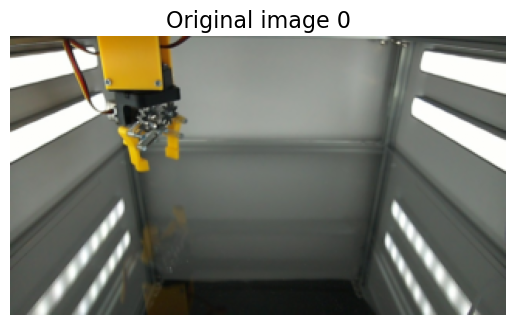

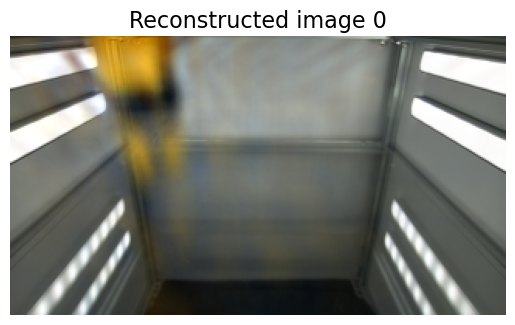

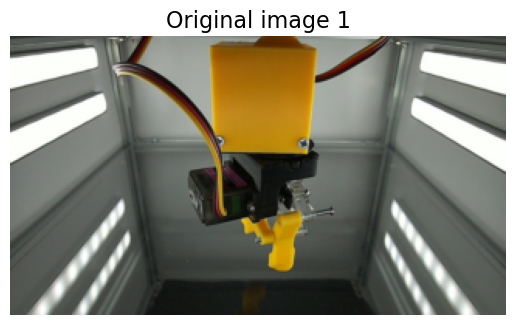

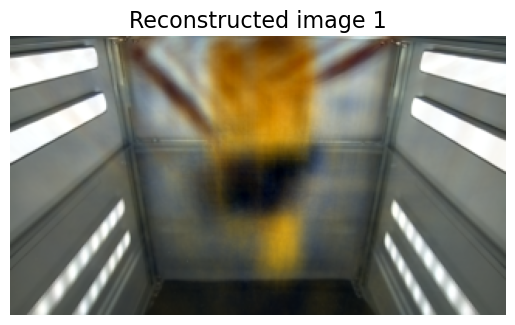

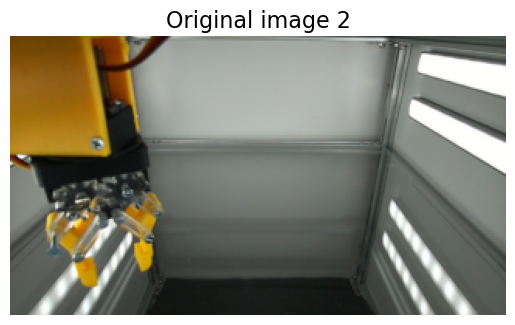

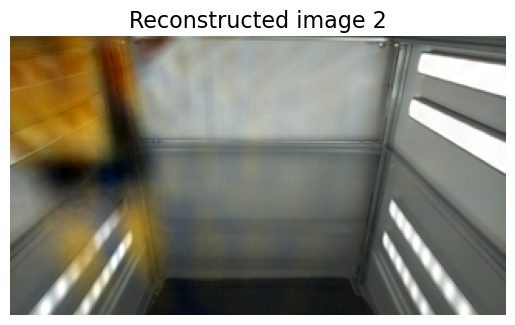

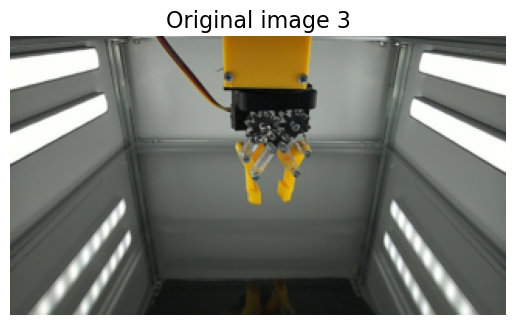

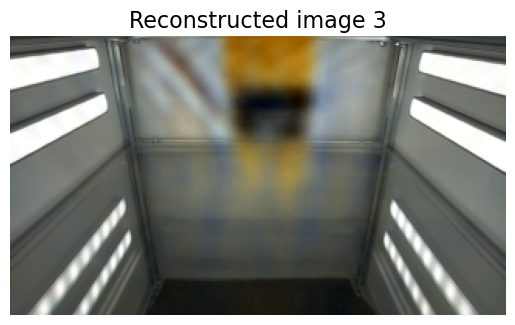

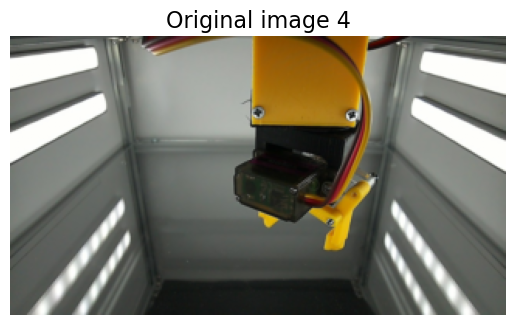

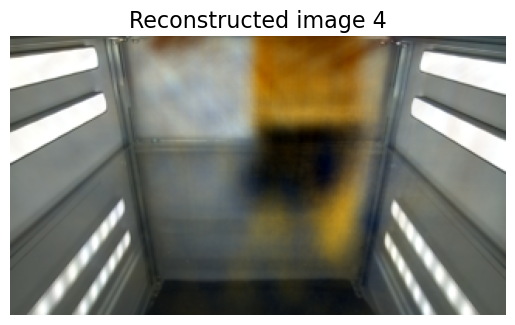

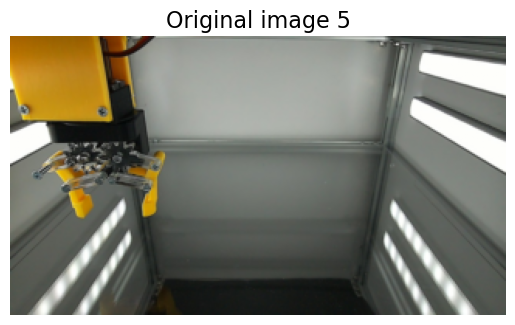

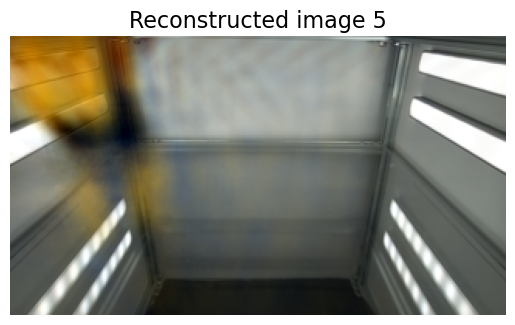

In [64]:
from gripper_data import transpose_channels_last
import matplotlib.pyplot as plt

print("Num components:", pca.n_components_)
batch = next(iter(dataloader))
bottom_images, top_images, states = batch

# Project new data into PCA space
projections = pca.transform(top_images - top_mean)
print("Projections shape:", projections.shape)

# Reconstruct data from projections
reconstructed = pca.inverse_transform(projections) + top_mean.numpy()

i = 0
for reconstruction, img in zip(reconstructed, top_images):
    img = np.reshape(img, (3,resize_shape[0],-1))
    plot_image(img, title=f"Original image {i}")
    reconstruction = np.reshape(reconstruction, (3,resize_shape[0],-1))
    plot_image(reconstruction, title=f"Reconstructed image {i}")
    i += 1
    if i>5:
        break

Select a custom number of components

C:\Users\UTENTE\AppData\Local\Temp\ipykernel_30276\3590430312.py:5: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  projections = (top_images - top_mean) @ selected_eigenvectors.T


Projections shape: torch.Size([200, 1])


C:\Users\UTENTE\AppData\Local\Temp\ipykernel_30276\3590430312.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reconstructed = projections @ selected_eigenvectors + top_mean.numpy()


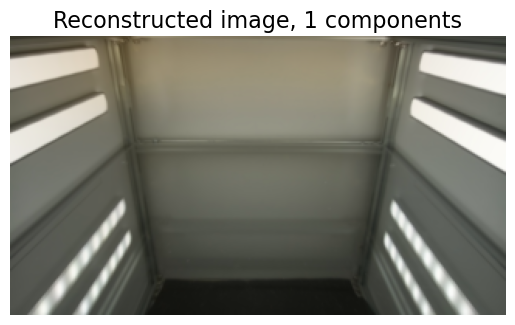

In [68]:
selected_components = 1
eigenvectors = pca.components_
selected_eigenvectors = eigenvectors[:selected_components]

projections = (top_images - top_mean) @ selected_eigenvectors.T
print("Projections shape:", projections.shape)

# Reconstruct data from projections
reconstructed = projections @ selected_eigenvectors + top_mean.numpy()
for reconstruction, img in zip(reconstructed, top_images):
    img = np.reshape(img, (3,resize_shape[0],-1))
    img = transpose_channels_last(img)
    reconstruction = np.reshape(reconstruction, (3,resize_shape[0],-1))
    plot_image(reconstruction,
                title=f"Reconstructed image, {selected_components} components")
    break

C:\Users\UTENTE\AppData\Local\Temp\ipykernel_30276\1879200815.py:9: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  projections = (top_images - top_mean) @ selected_eigenvectors.T


Projections shape: torch.Size([200, 1])


C:\Users\UTENTE\AppData\Local\Temp\ipykernel_30276\1879200815.py:13: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  reconstructed = projections @ selected_eigenvectors + top_mean.numpy()


Projections shape: torch.Size([200, 2])
Projections shape: torch.Size([200, 10])
Projections shape: torch.Size([200, 50])
Projections shape: torch.Size([200, 100])
Projections shape: torch.Size([200, 200])


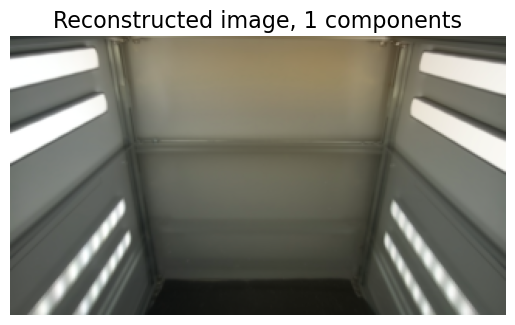

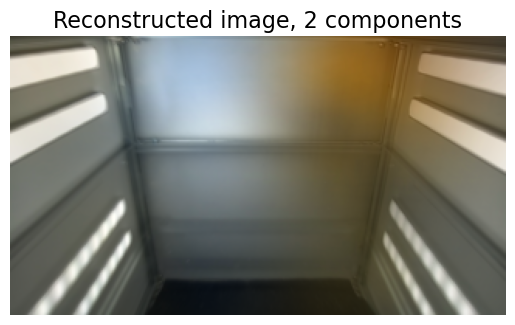

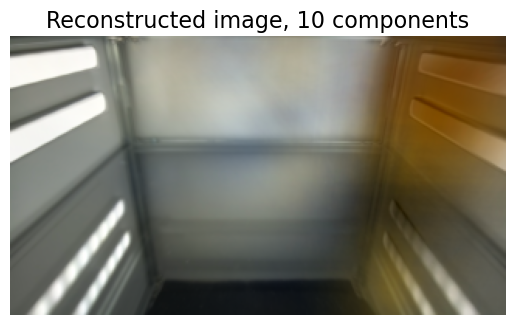

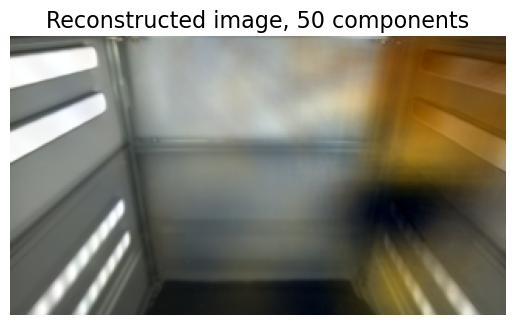

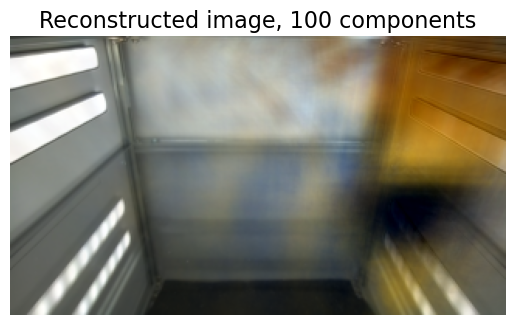

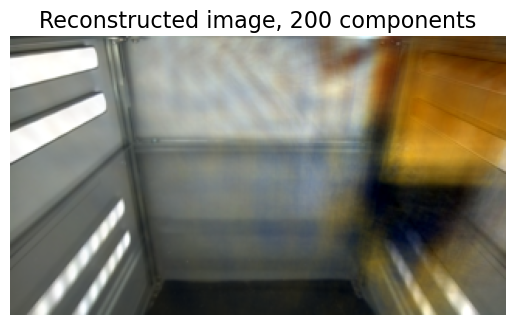

In [62]:
list_num_components = [1, 2, 10, 50, 100, 200]
# fig, ax = plt.subplots(nrows=len(list_num_components), 
#                        figsize=(10, 5*len(list_num_components)))
# ax = ax.flatten()

for selected_components in list_num_components:
    # projection along selected principal components
    selected_eigenvectors = eigenvectors[:selected_components]
    projections = (top_images - top_mean) @ selected_eigenvectors.T
    print("Projections shape:", projections.shape)

    # Reconstruct data from projections
    reconstructed = projections @ selected_eigenvectors + top_mean.numpy()

    # display reconstructed images
    for reconstruction, img in zip(reconstructed, top_images):
        img = np.reshape(img, (3,resize_shape[0],-1))
        img = transpose_channels_last(img)
        reconstruction = np.reshape(reconstruction, (3,resize_shape[0],-1))
        plot_image(reconstruction,
                   title=f"Reconstructed image, {selected_components} components")
                #    ax=ax[list_num_components.index(selected_components)])
        # plt.figure()
        # plt.imshow(img.numpy())
        break